# Predicting customer healthcare costs using the power of machine learning.

The insights from this will help tailor services and guide customers in planning their healthcare expenses more effectively.

**Dataset Summary**

The `insurance.csv` dataset. Packed with information on health insurance customers and their healthcare costs.

**insurance.csv**

| Column    | Data Type | Description                                                      |
|-----------|-----------|------------------------------------------------------------------|
| `age`       | int       | Age of the primary beneficiary.                                  |
| `sex`       | object    | Gender of the insurance contractor (male or female).             |
| `bmi`       | float     | Body mass index, a key indicator of body fat based on height and weight. |
| `children`  | int       | Number of dependents covered by the insurance plan.              |
| `smoker`    | object    | Indicates whether the beneficiary smokes (yes or no).            |
| `region`    | object    | The beneficiary's residential area in the US, divided into four regions. |
| `charges`   | float     | Individual medical costs billed by health insurance.             |


Import required libraries

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV
import shap

## Loading the datasets

In [73]:
insurance = pd.read_csv("/content/insurance.csv")
insurance_val = pd.read_csv("/content/validation_dataset.csv")

In [74]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19.0,female,27.900,0.0,yes,southwest,16884.924
1,18.0,male,33.770,1.0,no,Southeast,1725.5523
2,28.0,male,33.000,3.0,no,southeast,$4449.462
3,33.0,male,22.705,0.0,no,northwest,$21984.47061
4,32.0,male,28.880,0.0,no,northwest,$3866.8552


In [75]:
insurance_val.head()

,age,sex,bmi,children,smoker,region
0,18.0,female,24.090000,1.0,no,southeast
1,39.0,male,26.410000,0.0,yes,northeast
2,27.0,male,29.150000,0.0,yes,southeast
3,71.0,male,65.502135,13.0,yes,southeast
4,28.0,male,38.060000,0.0,no,southeast


## Process the dataset

In [76]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1272 non-null   float64
 1   sex       1272 non-null   object 
 2   bmi       1272 non-null   float64
 3   children  1272 non-null   float64
 4   smoker    1272 non-null   object 
 5   region    1272 non-null   object 
 6   charges   1284 non-null   object 
dtypes: float64(3), object(4)
memory usage: 73.3+ KB


In [77]:
insurance.isnull().sum()

,0
age,66
sex,66
bmi,66
children,66
smoker,66
region,66
charges,54


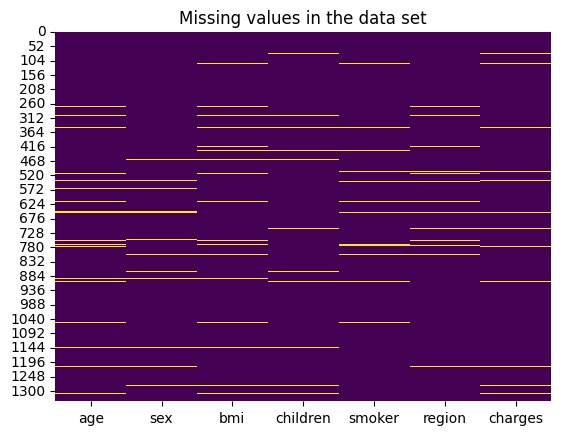

In [78]:
sns.heatmap(insurance.isnull(), cbar=False, cmap='viridis')
plt.title("Missing values in the data set")
plt.show()

Drop the missing values

In [79]:
insurance_fill = insurance.dropna()

In [80]:
insurance_fill.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


Formatting the `charges` column:
- removing the $ sign
- change the type to `float` from `object`

In [81]:
#insurance_fill['charges'] = insurance_fill['charges'].str.replace('$', '', regex=False).astype(float)

insurance_fill = (insurance_fill.assign(
        charges = insurance_fill['charges']
        .replace('$nan', np.nan)
        .str.replace('$', '', regex=False)
        .astype(float))
        .dropna(subset=['charges']))

In [83]:
insurance_fill.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1207 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1207 non-null   float64
 1   sex       1207 non-null   object 
 2   bmi       1207 non-null   float64
 3   children  1207 non-null   float64
 4   smoker    1207 non-null   object 
 5   region    1207 non-null   object 
 6   charges   1207 non-null   float64
dtypes: float64(4), object(3)
memory usage: 75.4+ KB


In [84]:
insurance_fill['charges'].dtype

dtype('float64')

Format the Categorical Columns

In [85]:
insurance_fill.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [86]:
categorical_cols = ['sex', 'smoker', 'region']
for col in categorical_cols:
       unique_values = insurance[col].unique()
       print(f"Column '{col}': {unique_values}")

Column 'sex': ['female' 'male' 'woman' 'F' 'man' nan 'M']
Column 'smoker': ['yes' 'no' nan]
Column 'region': ['southwest' 'Southeast' 'southeast' 'northwest' 'Northwest' 'Northeast'
 'northeast' 'Southwest' nan]


There seem to be some weired values there

In [87]:
insurance_fill['region'] = insurance_fill['region'].str.lower()

In [88]:
insurance_fill['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [89]:
insurance_fill['sex'].value_counts()

,count
sex,
male,494
female,479
M,61
woman,60
man,57
F,56


In [90]:
def clean_col(x):
  if x in ['male', 'man', 'M']:
    return 'Male'
  elif x in ['female', 'woman', 'F']:
    return 'Female'
  else:
    return x

insurance_fill['sex'] = insurance_fill['sex'].apply(clean_col)

In [91]:
insurance_fill['sex'].value_counts()

,count
sex,
Male,612
Female,595


In [92]:
insurance_fill.head()

,age,sex,bmi,children,smoker,region,charges
0,19.0,Female,27.900,0.0,yes,southwest,16884.92400
1,18.0,Male,33.770,1.0,no,southeast,1725.55230
2,28.0,Male,33.000,3.0,no,southeast,4449.46200
3,33.0,Male,22.705,0.0,no,northwest,21984.47061
4,32.0,Male,28.880,0.0,no,northwest,3866.85520


## Explanatory Data Analysis

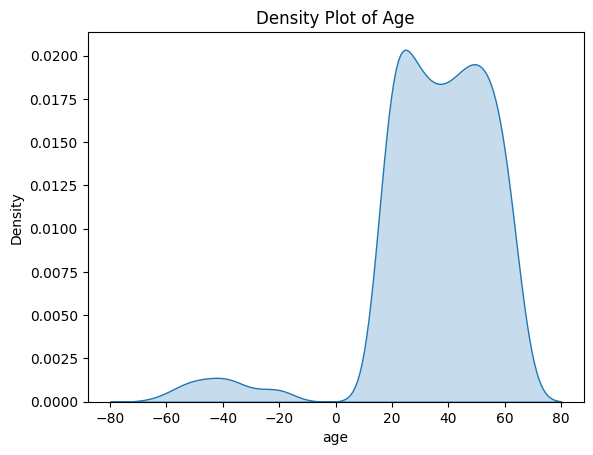

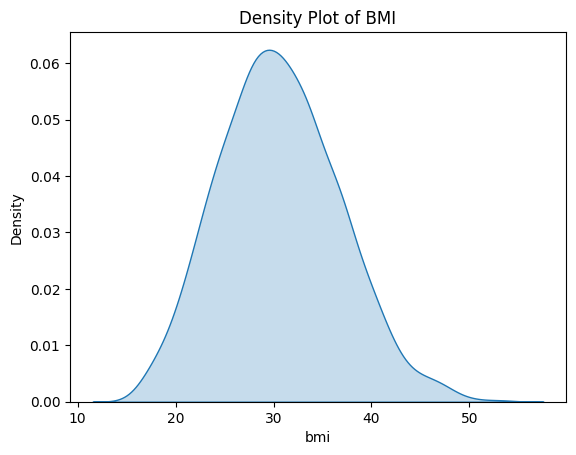

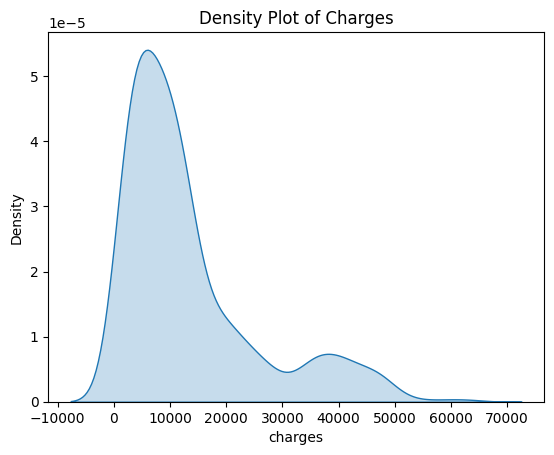

In [93]:
sns.kdeplot(insurance_fill['age'], fill=True)
plt.title('Density Plot of Age')
plt.show()

sns.kdeplot(insurance_fill['bmi'], fill=True)
plt.title('Density Plot of BMI')
plt.show()

sns.kdeplot(insurance_fill['charges'], fill=True)
plt.title('Density Plot of Charges')
plt.show()

This looks odd. There are some negative value in the age column and charges column. Why?

In [94]:
print(insurance_fill['charges'].min())

1121.8739


In [98]:
print(insurance_fill['age'].min())

-64.0


In [95]:
insurance_fix = insurance_fill.apply(lambda x: x.abs() if np.issubdtype(x.dtype, np.number) else x)

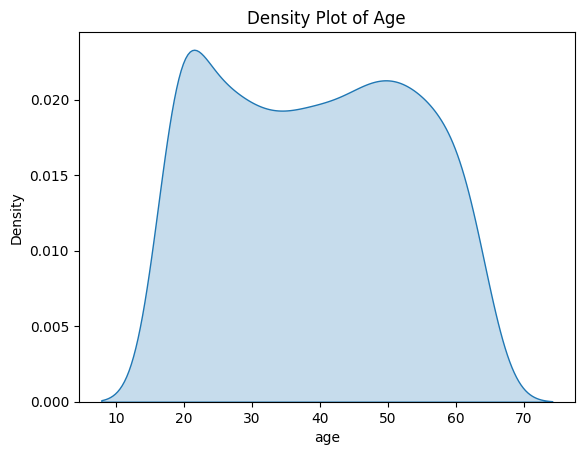

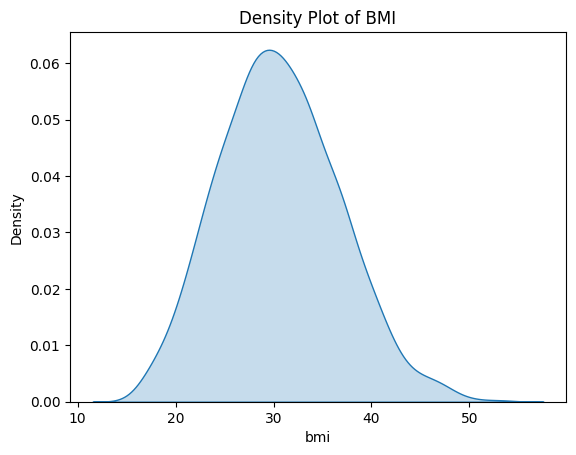

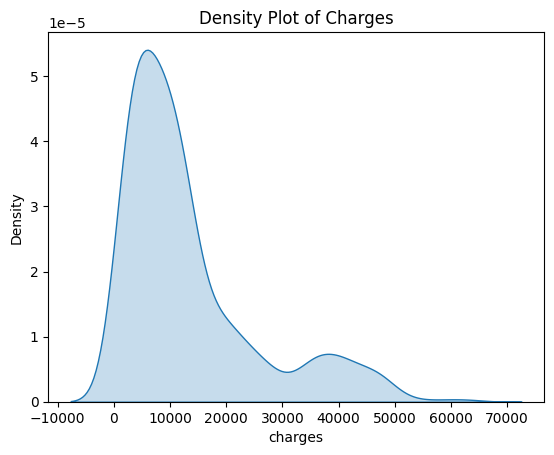

In [99]:
sns.kdeplot(insurance_fix['age'], fill=True)
plt.title('Density Plot of Age')
plt.show()

sns.kdeplot(insurance_fix['bmi'], fill=True)
plt.title('Density Plot of BMI')
plt.show()

sns.kdeplot(insurance_fix['charges'], fill=True)
plt.title('Density Plot of Charges')
plt.show()

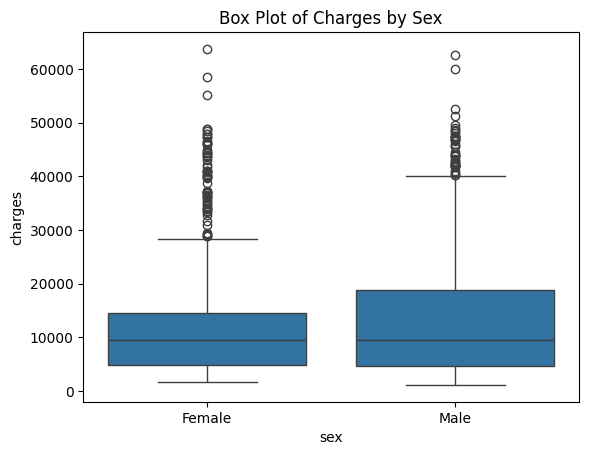

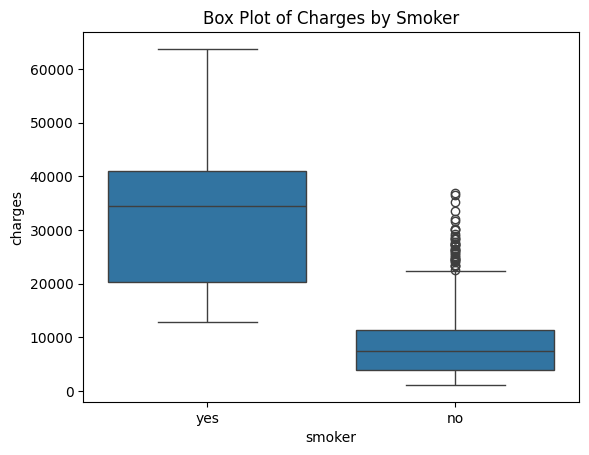

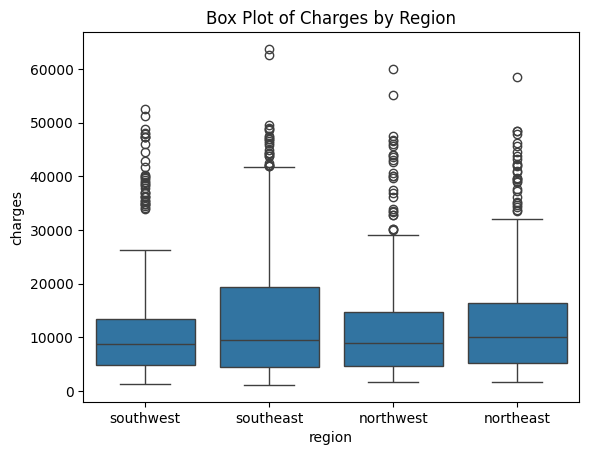

In [100]:
sns.boxplot(x='sex', y='charges', data=insurance_fix)
plt.title('Box Plot of Charges by Sex')
plt.show()

sns.boxplot(x='smoker', y='charges', data=insurance_fix)
plt.title('Box Plot of Charges by Smoker')
plt.show()

sns.boxplot(x='region', y='charges', data=insurance_fix)
plt.title('Box Plot of Charges by Region')
plt.show()

- Charges by Sex:

 - Similar median charges for males and females (~$9-10k)
 - Males show more variability and higher extreme costs
 - Both distributions are right-skewed

- Charges by Smoker Status:

  - Dramatic difference between smokers and non-smokers
  - Smokers have much higher median charges (~$35k vs ~$8k)
  - Smoker charges show wider spread
  - Non-smokers have more outliers but lower overall costs

- Charges by Region:

 - Similar median charges across all regions (~$8-10k)
 - Southeast shows slightly higher variability
 - All regions have numerous high-cost outliers
 - No strong regional effect on insurance charges

Most significant factor appears to be smoking status, with smokers paying substantially more for insurance. Sex and region have relatively minor impacts on charges in comparison.

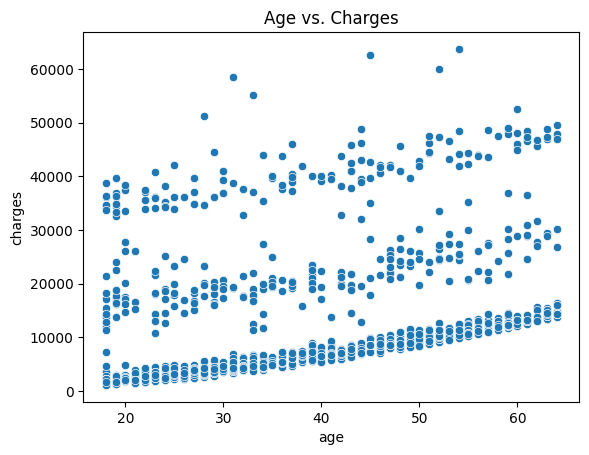

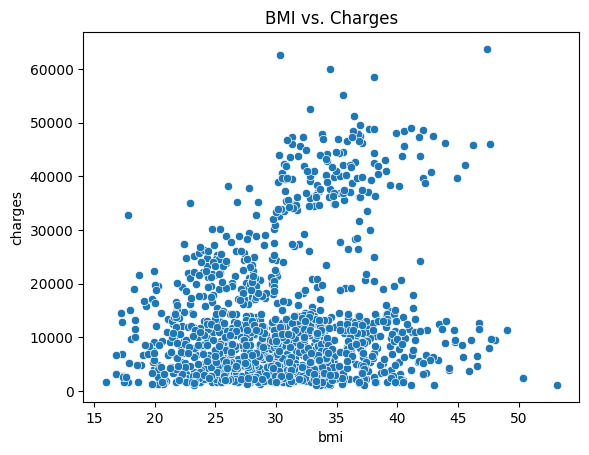

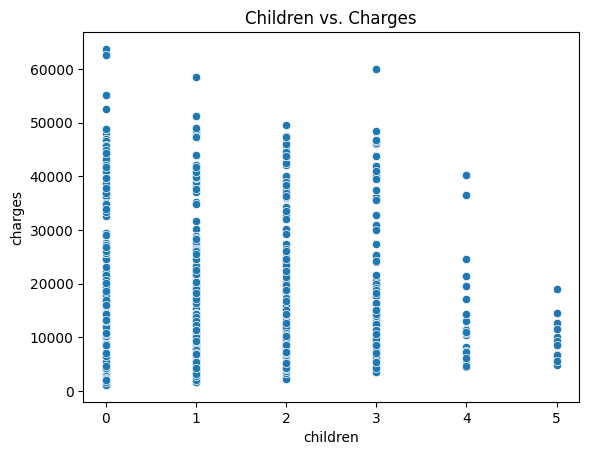

In [101]:
sns.scatterplot(x='age', y='charges', data=insurance_fix)
plt.title('Age vs. Charges')
plt.show()

sns.scatterplot(x='bmi', y='charges', data=insurance_fix)
plt.title('BMI vs. Charges')
plt.show()

sns.scatterplot(x='children', y='charges', data=insurance_fix)
plt.title('Children vs. Charges')
plt.show()

Looking at all scatter plots:

- Age vs. Charges:

 - Strong positive correlation between age and charges
 - Three distinct bands visible, suggesting other factors (likely smoking) influence the relationship
 - Charges increase steadily with age in all bands

- BMI vs. Charges:

 - Moderate positive correlation
 - More scattered pattern than age relationship
 - Higher BMIs tend to have higher charges, but with significant variation
 - Dense cluster of points in lower charges range (below $20k)

- Children vs. Charges:

 - No clear linear relationship
 - Similar charge distributions across 0-3 children
 - Fewer data points for 4-5 children
 - Vertical stripes pattern shows discrete nature of children variable

Overall, smoking status appears to be the primary driver of insurance charges, followed by age and BMI, while number of children and regional factors have minimal impact.

## Modeling

In [102]:
insurance_fix.head()

,age,sex,bmi,children,smoker,region,charges
0,19.0,Female,27.900,0.0,yes,southwest,16884.92400
1,18.0,Male,33.770,1.0,no,southeast,1725.55230
2,28.0,Male,33.000,3.0,no,southeast,4449.46200
3,33.0,Male,22.705,0.0,no,northwest,21984.47061
4,32.0,Male,28.880,0.0,no,northwest,3866.85520


Converting categorical columns to numerical using one-hot encoding

In [103]:
insurance_encoded = pd.get_dummies(insurance_fix, columns=['sex', 'smoker', 'region'], drop_first=True)

In [104]:
insurance_encoded.head()

,age,bmi,children,charges,sex_Male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19.0,27.900,0.0,16884.92400,False,True,False,False,True
1,18.0,33.770,1.0,1725.55230,True,False,False,True,False
2,28.0,33.000,3.0,4449.46200,True,False,False,True,False
3,33.0,22.705,0.0,21984.47061,True,False,True,False,False
4,32.0,28.880,0.0,3866.85520,True,False,True,False,False


In [105]:
# Convert boolean columns to 0/1
insurance_encoded[['sex_Male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']] = \
    insurance_encoded[['sex_Male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']].astype(int)

In [108]:
insurance_encoded.head()

,age,bmi,children,charges,sex_Male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19.0,27.900,0.0,16884.92400,0,1,0,0,1
1,18.0,33.770,1.0,1725.55230,1,0,0,1,0
2,28.0,33.000,3.0,4449.46200,1,0,0,1,0
3,33.0,22.705,0.0,21984.47061,1,0,1,0,0
4,32.0,28.880,0.0,3866.85520,1,0,1,0,0


Test, Train, and Val Split

In [109]:
X = insurance_encoded.drop('charges', axis=1)
y = insurance_encoded['charges']

# Split data into training and temporary sets (test + validation)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.35, random_state=42) # 60% train, 35% temp


# Split the temporary set into test and validation sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42) #Splitting the 40% into half for test and validation (20% each)

### Linear Regression

In [110]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [111]:
# Make predictions on the validation set
y_pred_val = model.predict(X_val)

In [112]:
# Evaluate the model
mse_val = mean_squared_error(y_val, y_pred_val)
r2_val = r2_score(y_val, y_pred_val)

In [113]:
print(f"Validation MSE: {mse_val}")
print(f"Validation R-squared: {r2_val}")

Validation MSE: 35647527.02285426
Validation R-squared: 0.7384414562853887


The linear regression model explains about 74% of the variance in insurance charges (R-squared = 0.74)

### Random forest

In [114]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [115]:
# Make predictions
y_pred_val = model.predict(X_val)

In [116]:
# Evaluate the model
mse_valRf = mean_squared_error(y_val, y_pred_val)
r2_valRf = r2_score(y_val, y_pred_val)

In [117]:
print(f"Validation MSE: {mse_valRf}")
print(f"Validation R-squared: {r2_valRf}")

Validation MSE: 26936713.355104364
Validation R-squared: 0.8023557843689407


The Random forest model explains about 80% of the variance in insurance charges (R-squared = 0.80) with an average squared prediction error of around $26.9 million (MSE), indicating reasonably good but not perfect predictive performance.

### Hyperparameter tuning

In [119]:
# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [120]:
# Create the model
model = RandomForestRegressor(random_state=42)

# Create GridSearchCV object
grid_search = GridSearchCV(estimator=model, param_grid=param_grid,
                          scoring='neg_mean_squared_error', cv=5, n_jobs=-1)

In [121]:
# Fit the grid search to the data
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='neg_mean_squared_error')

In [122]:
# Get the best parameters
best_params = grid_search.best_params_
print(f"Best parameters: {best_params}")

Best parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}


In [123]:
# Get the best model
best_model = grid_search.best_estimator_

In [124]:
# Make predictions on the validation set using the best model
y_pred_val = best_model.predict(X_val)

In [125]:
# Evaluate the best model
mse_val = mean_squared_error(y_val, y_pred_val)
r2_val = r2_score(y_val, y_pred_val)

print(f"Validation MSE (after tuning): {mse_val}")
print(f"Validation R-squared (after tuning): {r2_val}")

Validation MSE (after tuning): 23621160.730339468
Validation R-squared (after tuning): 0.8266831694239175


The best Random forest model explains about 83% of the variance in insurance charges (R-squared = 0.83) with an average squared prediction error of around $23.6 million (MSE).

Making predictions on the test set

In [126]:
y_pred_test = best_model.predict(X_test)

In [127]:
# Evaluate the model on the test set
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

In [128]:
print(f"Test MSE: {mse_test}")
print(f"Test R-squared: {r2_test}")

Test MSE: 18506383.402098842
Test R-squared: 0.8605883706312711


The best Random forest model explains about 86% of the variance in insurance charges (R-squared = 0.86) with an average squared prediction error of around $18.5 million (MSE) in the test dataset. So, a significant improvement over the initial model.

## XAI (Explainable AI) techniques to understand feature importance and gain insights into model's predictions

In [130]:
# Create the explainer
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

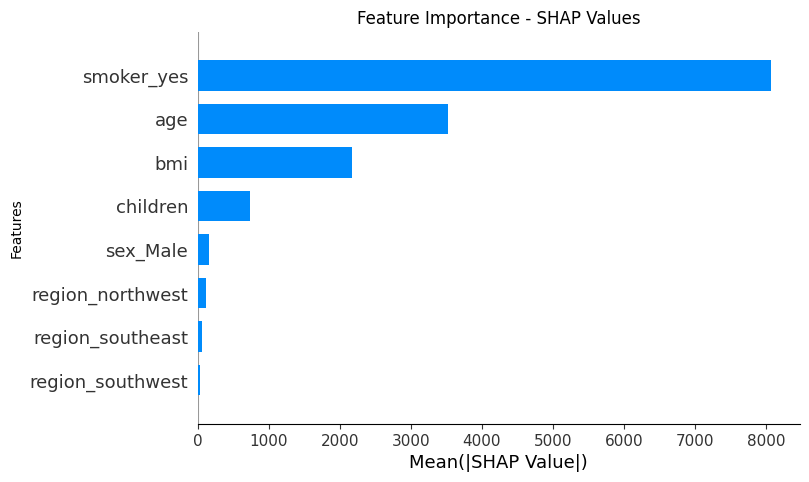

In [134]:
# Summarize feature importance
shap.summary_plot(shap_values, X_test, plot_type="bar",
                  show=False)

plt.title("Feature Importance - SHAP Values")
plt.xlabel("Mean(|SHAP Value|)")
plt.ylabel("Features")
plt.show()

This SHAP value plot shows the relative importance of features in predicting insurance charges:

Smoking status has by far the largest impact (aprox 8000), followed by age (aprox 3500) and BMI (aprox 2000). The number of children has minimal impact, while sex and regional differences have negligible influence on charges. This aligns with our earlier exploratory analysis where smoking was identified as the primary driver of insurance costs.

In [133]:
shap.initjs()
# Visualize individual predictions
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test.iloc[0,:])